In [1]:
#LOAN PREDICTION MODEL


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

print("✅ Library imported successfully!")

✅ Library imported successfully!


In [6]:
#load and explore data
df=pd.read_csv('Loan_Default.csv')

print("=" *60)
print("DATA OVERVIEW")
print("="*60)
print(f"Number of rows:{df.shape[0]}")
print(f"Nomber of columns:{df.shape[1]}")
print("\n First 5 rows:")
df.head()


DATA OVERVIEW
Number of rows:5488
Nomber of columns:34

 First 5 rows:


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758.0,CIB,25-34,to_inst,98.728814,south,direct,1.0,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552.0,EXP,55-64,to_inst,NaN,North,direct,1.0,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834.0,CIB,35-44,to_inst,80.019685,south,direct,0.0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587.0,CIB,45-54,not_inst,69.376900,North,direct,0.0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.0,EXP,25-34,not_inst,91.886544,North,direct,0.0,39.0


In [8]:
# ============================================================
# LOAN VALIDATION FUNCTION 
# ============================================================

def validate_loan(loan_data):
    """
    Check if loan is valid BEFORE sending to model.
    Returns: (is_valid, error_messages, warning_messages)
    """
    errors = []
    warnings = []
    
    # 1. Loan Amount Check
    if loan_data['loan_amount'] < 1000:
        errors.append(f"Loan amount (KES {loan_data['loan_amount']:,.0f}) is below minimum (KES 1,000)")
    elif loan_data['loan_amount'] > 50_000_000:
        errors.append(f"Loan amount (KES {loan_data['loan_amount']:,.0f}) exceeds maximum (KES 50,000,000)")
    
    # 2. Income Check
    if loan_data['income'] < 1000:
        errors.append(f"Income (KES {loan_data['income']:,.0f}) is below minimum (KES 1,000)")
    
    # 3. Loan-to-Income Ratio (Should be less than 500x)
    if loan_data['income'] > 0:
        loan_to_income = loan_data['loan_amount'] / loan_data['income']
        if loan_to_income > 500:
            errors.append(f"Loan is {loan_to_income:,.0f}x monthly income (maximum 500x)")
        elif loan_to_income > 200:
            warnings.append(f"Loan is {loan_to_income:,.0f}x monthly income (high risk)")
    
    # 4. Property Value Check
    if loan_data['property_value'] < 1000:
        errors.append(f"Property value (KES {loan_data['property_value']:,.0f}) is below minimum (KES 1,000)")
    
    # 5. Loan-to-Value Ratio
    if loan_data['property_value'] > 0:
        ltv = (loan_data['loan_amount'] / loan_data['property_value']) * 100
        if ltv > 100:
            errors.append(f"LTV ({ltv:.1f}%) exceeds 100% - loan exceeds property value")
        elif ltv > 85:
            warnings.append(f"LTV ({ltv:.1f}%) is high (recommended < 80%)")
    
    # 6. Credit Score Check
    if loan_data['Credit_Score'] < 300:
        errors.append(f"Credit score ({loan_data['Credit_Score']}) is below minimum (300)")
    elif loan_data['Credit_Score'] < 400:
        warnings.append(f"Credit score ({loan_data['Credit_Score']}) is very poor")
    elif loan_data['Credit_Score'] < 550:
        warnings.append(f"Credit score ({loan_data['Credit_Score']}) is poor")
    
    # 7. Interest Rate Check
    if loan_data['rate_of_interest'] < 1:
        errors.append(f"Interest rate ({loan_data['rate_of_interest']}%) is below minimum (1%)")
    elif loan_data['rate_of_interest'] > 30:
        errors.append(f"Interest rate ({loan_data['rate_of_interest']}%) exceeds maximum (30%)")
    
    # 8. Loan Term Check
    if loan_data['term'] < 6:
        errors.append(f"Loan term ({loan_data['term']:.0f} months) is below minimum (6 months)")
    elif loan_data['term'] > 60:
        errors.append(f"Loan term ({loan_data['term']:.0f} months) exceeds maximum (60 months)")
    
    # 9. DTI Check
    if loan_data['dtir1'] > 60:
        errors.append(f"DTI ({loan_data['dtir1']:.1f}%) exceeds maximum (60%)")
    elif loan_data['dtir1'] > 45:
        warnings.append(f"DTI ({loan_data['dtir1']:.1f}%) is high")
    
    # 10. Upfront Charges Check
    if loan_data['Upfront_charges'] < 0:
        errors.append(f"Upfront charges (KES {loan_data['Upfront_charges']:,.0f}) cannot be negative")
    
    # 11. Property Value vs Loan Check
    if loan_data['property_value'] < loan_data['loan_amount'] * 0.3:
        warnings.append(f"Property value (KES {loan_data['property_value']:,.0f}) is less than 30% of loan amount")
    
    return len(errors) == 0, errors, warnings

In [9]:
# ============================================================
# DATA PREPROCESSING
# ============================================================
print("=" * 60)
print("FEATURES BEFORE PROCESSING")
print("=" * 60)

# Separate features and target
x = df.drop('Status', axis=1)
y = df['Status']

print(f"Number of features: {x.shape[1]}")
print(f"Feature Names: {x.columns.tolist()}")

# Remove columns with >60% missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
cols_to_drop = missing_percentage[missing_percentage > 60].index.tolist()
print(f"\nColumns to drop (missing >60%): {cols_to_drop}")

# Drop non-predictive columns
cols_to_drop.extend(['ID', 'year', 'loan_limit', 'Gender', 'loan_type', 'loan_purpose'])
X = x.drop(columns=cols_to_drop, errors='ignore')

print(f"\nFeatures after removing non-predictive columns: {X.shape[1]}")
print(f"Remaining Features: {X.columns.tolist()}")

FEATURES BEFORE PROCESSING
Number of features: 33
Feature Names: ['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'dtir1']

Columns to drop (missing >60%): []

Features after removing non-predictive columns: 27
Remaining Features: ['approv_in_adv', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_

In [10]:
# ============================================================
# HANDLE NUMERICAL VARIABLES (Fill Missing Values)
# ============================================================

from sklearn.impute import SimpleImputer

print("=" * 60)
print("NUMERICAL VARIABLES - IMPUTATION")
print("=" * 60)

# Identify numerical columns
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {len(numerical_cols)}")
print(f"Numerical columns: {numerical_cols}")

# Fill missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X[numerical_cols]),
    columns=numerical_cols
)

print(f"\n✅ Missing values filled with median")
print(f"Shape after imputation: {X_imputed.shape}")
print(f"Features: {X_imputed.columns.tolist()}")

# Check if any missing values remain
print(f"\nMissing values after imputation: {X_imputed.isnull().sum().sum()}")

NUMERICAL VARIABLES - IMPUTATION
Numerical columns: 10
Numerical columns: ['loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']

✅ Missing values filled with median
Shape after imputation: (5488, 10)
Features: ['loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']

Missing values after imputation: 0


In [12]:
# ============================================================
#  Remove rows with missing target values
# ============================================================
print("\n" + "=" * 60)
print("FIXING MISSING TARGET VALUES")
print("=" * 60)

print(f"Missing values in target (y): {y.isnull().sum()}")

valid_indices = y.notna()
print(f"Valid rows: {valid_indices.sum()}")
print(f"Rows to remove: {(~valid_indices).sum()}")

X_imputed_clean = X_imputed[valid_indices]
y_clean = y[valid_indices]

print(f"\n✅ Cleaned dataset:")
print(f"  • Features: {X_imputed_clean.shape}")
print(f"  • Target: {y_clean.shape}")


FIXING MISSING TARGET VALUES
Missing values in target (y): 1
Valid rows: 5487
Rows to remove: 1

✅ Cleaned dataset:
  • Features: (5487, 10)
  • Target: (5487,)



TOP FEATURES CORRELATED WITH LOAN DEFAULT
LTV                     0.090239
dtir1                   0.087925
Credit_Score            0.002775
rate_of_interest       -0.044127
term                   -0.044636
loan_amount            -0.046538
Interest_rate_spread   -0.049511
income                 -0.050319
property_value         -0.083136
Upfront_charges        -0.096708
dtype: float64


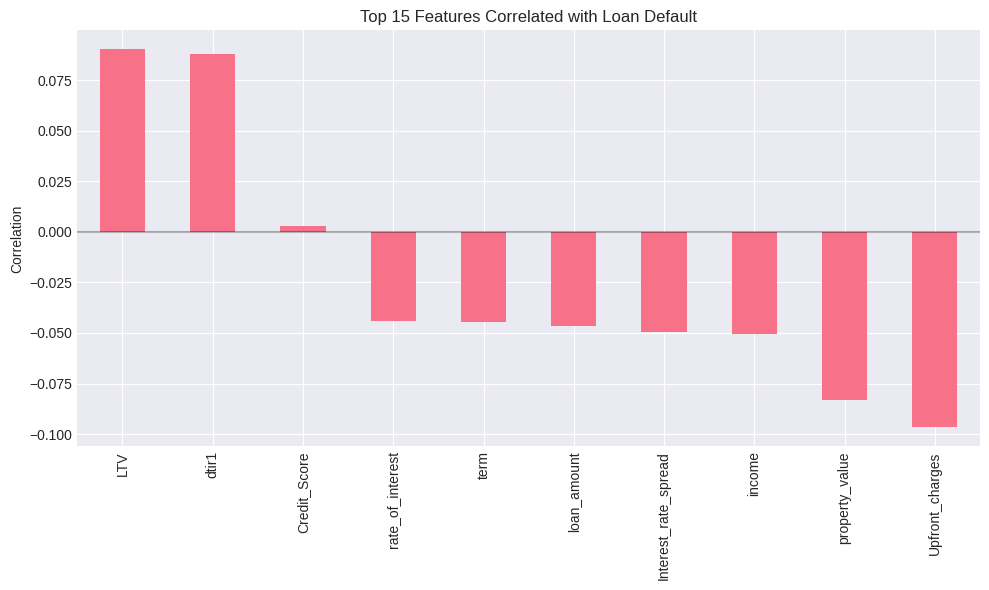

In [13]:
# ============================================================
# FEATURE ANALYSIS
# ============================================================
# Correlation with target
correlations = X_imputed_clean.corrwith(y_clean).sort_values(ascending=False)
print("\n" + "=" * 60)
print("TOP FEATURES CORRELATED WITH LOAN DEFAULT")
print("=" * 60)
print(correlations.head(10))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 6))
correlations.head(15).plot(kind='bar', ax=ax)
ax.set_title('Top 15 Features Correlated with Loan Default')
ax.set_ylabel('Correlation')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

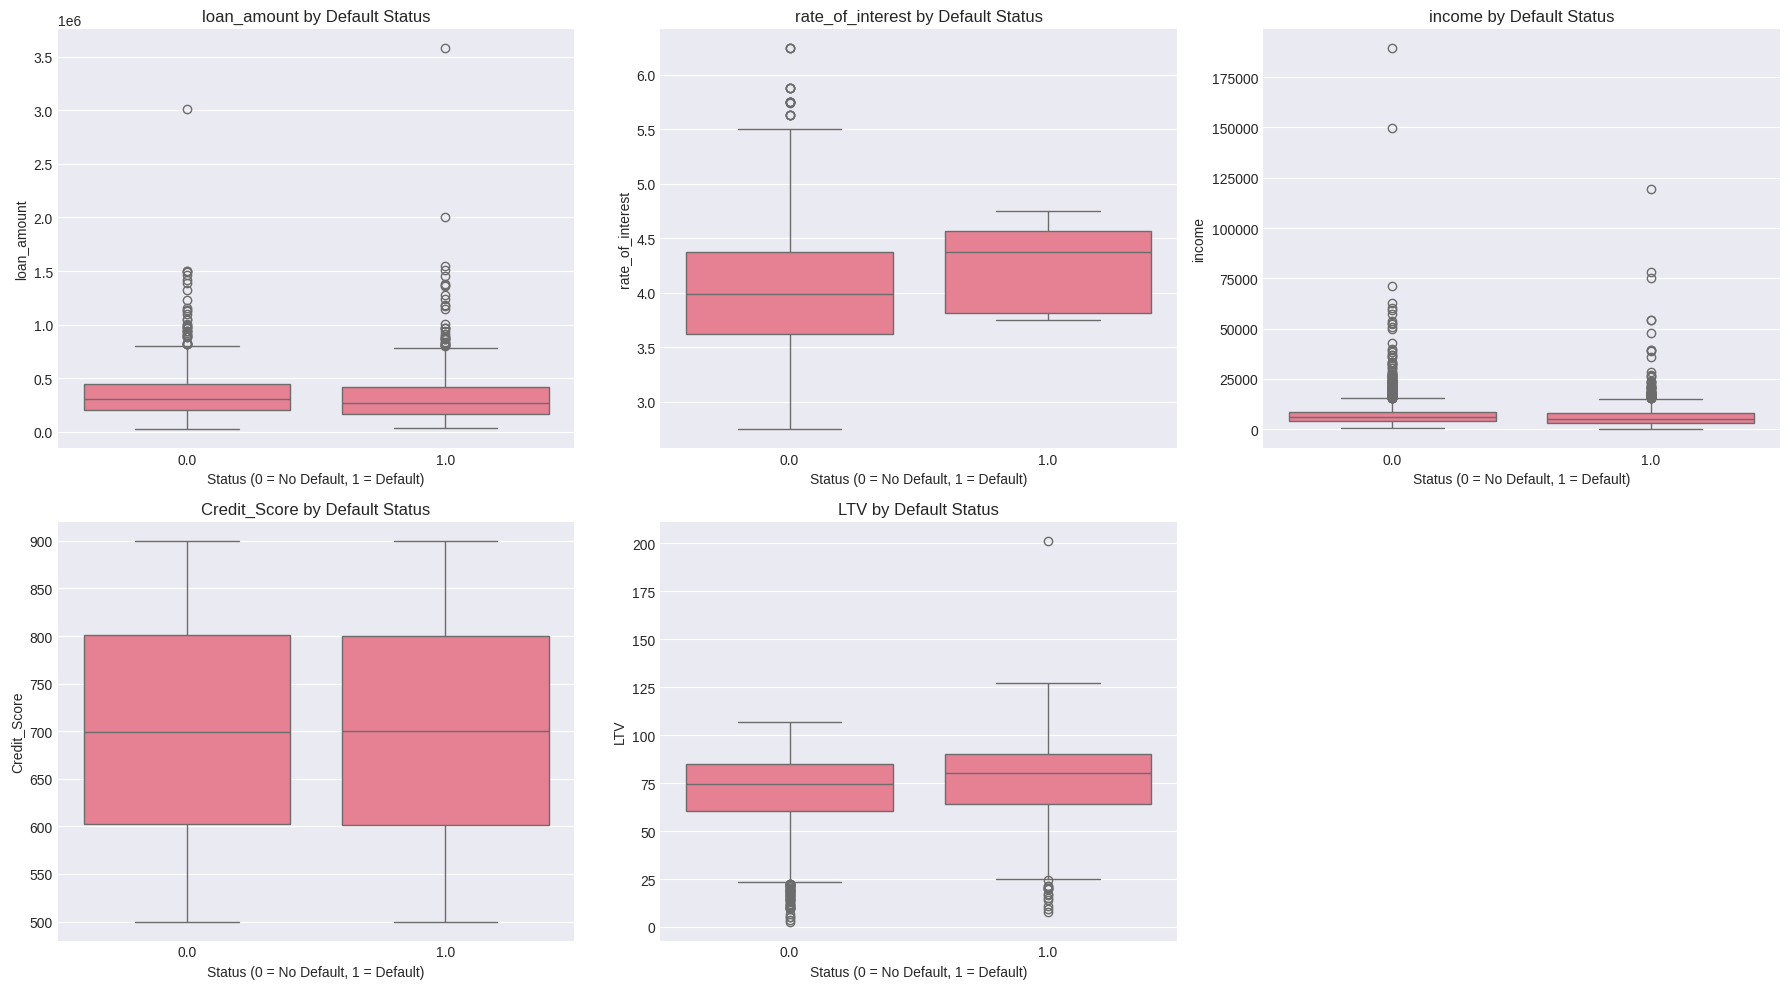

In [14]:
# ============================================================
# ANALYZE KEY FINANCIAL INDICATORS
# ============================================================
key_features = ['loan_amount', 'rate_of_interest', 'income', 'Credit_Score', 'LTV']
existing_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(existing_features):
    if i < len(existing_features):
        ax = axes[i]  # ✅ FIXED: Use current index
        sns.boxplot(data=df, x='Status', y=feature, ax=ax)
        ax.set_title(f'{feature} by Default Status')
        ax.set_xlabel('Status (0 = No Default, 1 = Default)')

# Hide extra subplots
for j in range(len(existing_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
#MODEL TRAINING



In [17]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================
print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

x_train, x_test, y_train, y_test = train_test_split(
    X_imputed_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean  # ✅ FIXED
)

print(f"Training set: {x_train.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")
print(f"\nTraining distribution:\n{y_train.value_counts()}")
print(f"\nTest distribution:\n{y_test.value_counts()}")

TRAIN-TEST SPLIT
Training set: 4389 samples
Test set: 1098 samples

Training distribution:
Status
0.0    3319
1.0    1070
Name: count, dtype: int64

Test distribution:
Status
0.0    830
1.0    268
Name: count, dtype: int64


In [18]:
# ============================================================
# SCALE NUMERICAL FEATURES
# ============================================================
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("\n✅ Features scaled using StandardScaler")


✅ Features scaled using StandardScaler


In [20]:
# ============================================================
# TRAIN RANDOM FOREST MODEL
# ============================================================
print("\n" + "=" * 60)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(x_train_scaled, y_train)

y_pred_rf = rf_model.predict(x_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n✅ Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


TRAINING RANDOM FOREST CLASSIFIER

✅ Random Forest Accuracy: 0.9991

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       830
         1.0       1.00      1.00      1.00       268

    accuracy                           1.00      1098
   macro avg       1.00      1.00      1.00      1098
weighted avg       1.00      1.00      1.00      1098



In [22]:
# ============================================================
# TRAIN LOGISTIC REGRESSION
# ============================================================
print("\n" + "=" * 60)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42)
lr_model.fit(x_train_scaled, y_train)

y_pred_lr = lr_model.predict(x_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"\n✅ Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


TRAINING LOGISTIC REGRESSION

✅ Logistic Regression Accuracy: 0.6084

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.57      0.69       830
         1.0       0.35      0.73      0.48       268

    accuracy                           0.61      1098
   macro avg       0.61      0.65      0.58      1098
weighted avg       0.74      0.61      0.64      1098



In [24]:
# ============================================================
# CROSS-VALIDATION TO CHECK MODEL PERFORMANCE
# ============================================================

from sklearn.model_selection import cross_val_score

print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)

# Cross-validation for Random Forest
cv_scores_rf = cross_val_score(rf_model, x_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nRandom Forest CV Scores: {cv_scores_rf}")
print(f"Random Forest Mean CV Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std()*2:.4f})")

# Cross-validation for Logistic Regression
cv_scores_lr = cross_val_score(lr_model, x_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nLogistic Regression CV Scores: {cv_scores_lr}")
print(f"Logistic Regression Mean CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std()*2:.4f})")


CROSS-VALIDATION RESULTS

Random Forest CV Scores: [0.99886105 0.9977221  1.         1.         0.99885975]
Random Forest Mean CV Accuracy: 0.9991 (+/- 0.0017)

Logistic Regression CV Scores: [0.61047836 0.60820046 0.57972665 0.5785877  0.59749145]
Logistic Regression Mean CV Accuracy: 0.5949 (+/- 0.0272)



MODEL COMPARISON


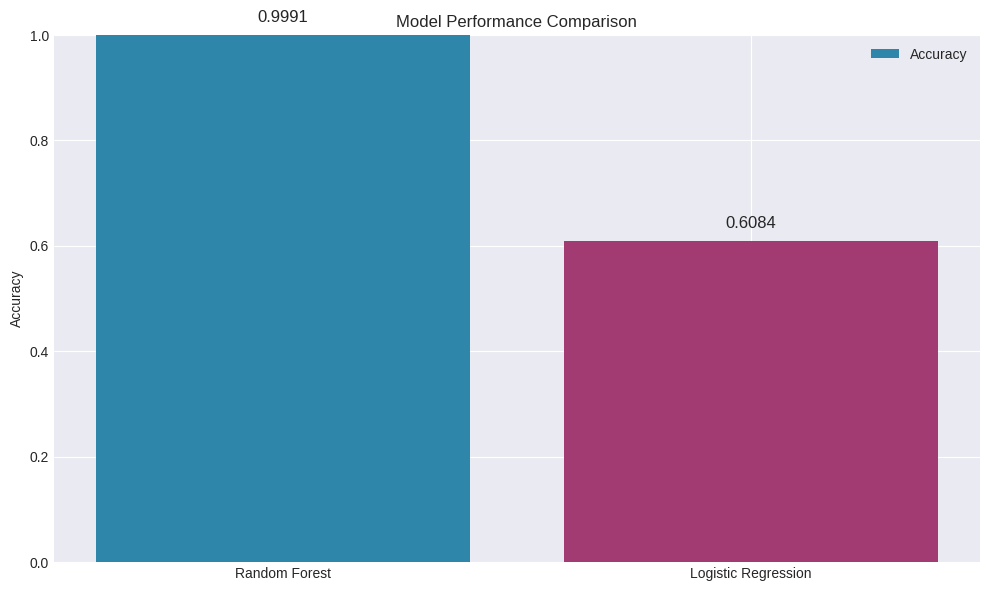


📊 Best model: Random Forest
✅ Best accuracy: 0.9991


In [25]:
# ============================================================
# MODEL COMPARISON
# ============================================================
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

models = ['Random Forest', 'Logistic Regression']
accuracies = [accuracy_rf, accuracy_lr]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies, color=['#2E86AB', '#A23B72'])
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison')

# Add value labels
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=12)

ax.legend(['Accuracy'])
plt.tight_layout()
plt.show()

print(f"\n📊 Best model: {'Random Forest' if accuracy_rf > accuracy_lr else 'Logistic Regression'}")
print(f"✅ Best accuracy: {max(accuracy_rf, accuracy_lr):.4f}")


TOP 20 IMPORTANT FEATURES
                feature  importance
2  Interest_rate_spread    0.413133
3       Upfront_charges    0.284270
1      rate_of_interest    0.222015
5        property_value    0.032929
8                   LTV    0.023695
9                 dtir1    0.013885
6                income    0.004409
0           loan_amount    0.003192
4                  term    0.001789
7          Credit_Score    0.000683


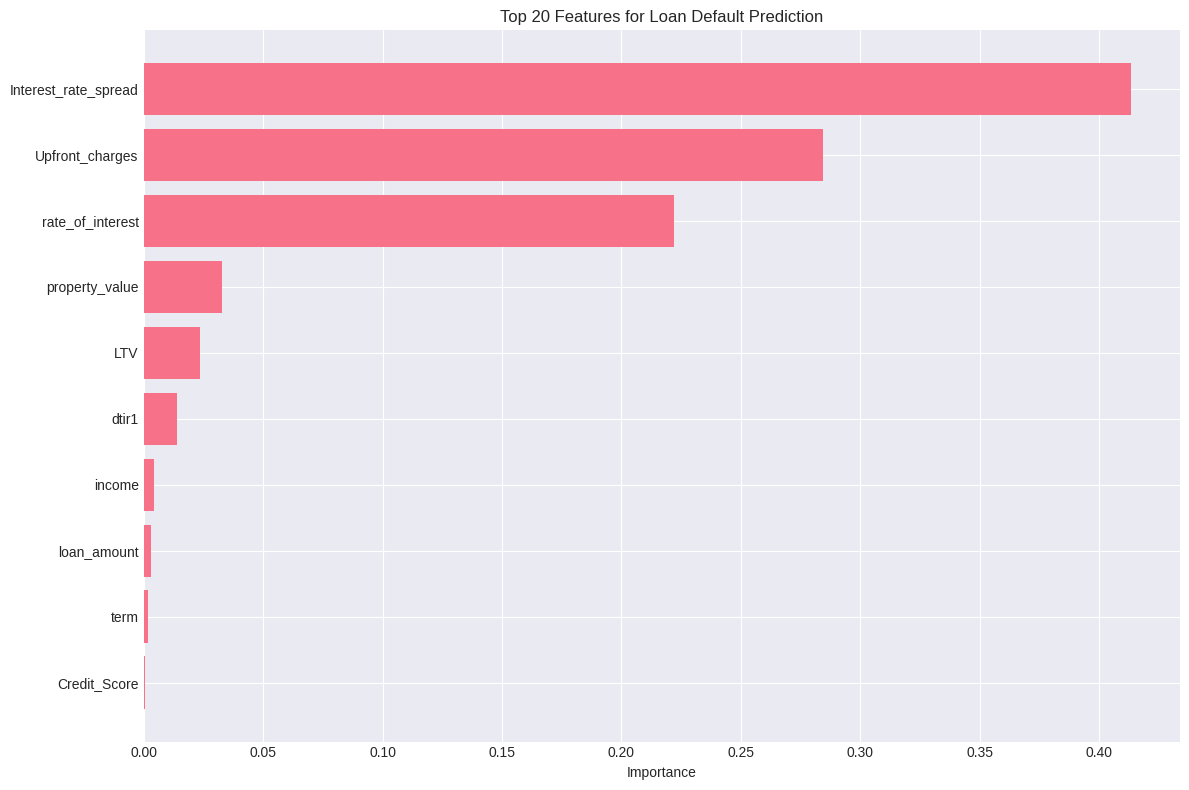

In [26]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================
feature_importance = pd.DataFrame({
    'feature': X_imputed_clean.columns,  # ✅ FIXED
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)
print(feature_importance.head(20))

fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(20)
ax.barh(top_features['feature'], top_features['importance'])
ax.set_xlabel('Importance')
ax.set_title('Top 20 Features for Loan Default Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

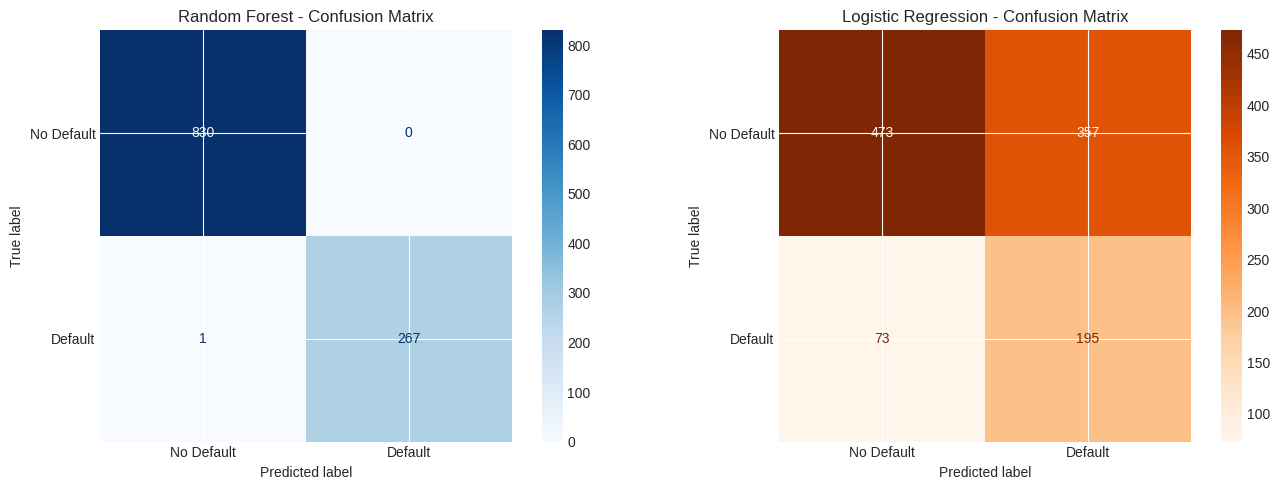

In [27]:
# ============================================================
# CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Default', 'Default'])
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Random Forest - Confusion Matrix')

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Default', 'Default'])
disp_lr.plot(ax=axes[1], cmap='Oranges', values_format='d')  # ✅ FIXED: axes[1]
axes[1].set_title('Logistic Regression - Confusion Matrix')

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# PERFORMANCE METRICS
# ============================================================
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

print("\n" + "=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)

print(f"\nRandom Forest")
print(f"  True Positives (Default predicted correctly): {tp_rf}")
print(f"  True Negatives (No Default predicted correctly): {tn_rf}")
print(f"  False Positives (False alarms): {fp_rf}")
print(f"  False Negatives (Missed defaults): {fn_rf}")
print(f"  Precision: {tp_rf/(tp_rf+fp_rf):.4f}")
print(f"  Recall: {tp_rf/(tp_rf+fn_rf):.4f}")
print(f"  F1-Score: {2*tp_rf/(2*tp_rf+fp_rf+fn_rf):.4f}")

print(f"\nLogistic Regression")
print(f"  True Positives (Default predicted correctly): {tp_lr}")
print(f"  True Negatives (No Default predicted correctly): {tn_lr}")
print(f"  False Positives (False alarms): {fp_lr}")
print(f"  False Negatives (Missed defaults): {fn_lr}")
print(f"  Precision: {tp_lr/(tp_lr+fp_lr):.4f}")
print(f"  Recall: {tp_lr/(tp_lr+fn_lr):.4f}")
print(f"  F1-Score: {2*tp_lr/(2*tp_lr+fp_lr+fn_lr):.4f}")


PERFORMANCE METRICS

Random Forest
  True Positives (Default predicted correctly): 267
  True Negatives (No Default predicted correctly): 830
  False Positives (False alarms): 0
  False Negatives (Missed defaults): 1
  Precision: 1.0000
  Recall: 0.9963
  F1-Score: 0.9981

Logistic Regression
  True Positives (Default predicted correctly): 195
  True Negatives (No Default predicted correctly): 473
  False Positives (False alarms): 357
  False Negatives (Missed defaults): 73
  Precision: 0.3533
  Recall: 0.7276
  F1-Score: 0.4756


In [29]:
# ============================================================
# TEST ON KNOWN RISKY LOANS
# ============================================================

print("\n" + "=" * 60)
print("🧪 TESTING ON RISKY LOAN SCENARIOS")
print("=" * 60)

# Create test cases
test_cases = [
    {
        'name': 'Extreme Risk Loan',
        'data': {
            'loan_amount': 5000000,
            'rate_of_interest': 16.0,
            'Interest_rate_spread': 7.0,
            'Upfront_charges': 70000,
            'term': 60,
            'property_value': 200000,
            'income': 30000,
            'Credit_Score': 500,
            'LTV': 166.7,
            'dtir1': 55
        }
    },
    {
        'name': 'Safe Loan',
        'data': {
            'loan_amount': 300000,
            'rate_of_interest': 6.5,
            'Interest_rate_spread': 1.5,
            'Upfront_charges': 3000,
            'term': 24,
            'property_value': 600000,
            'income': 75000,
            'Credit_Score': 750,
            'LTV': 50,
            'dtir1': 20
        }
    }
]

feature_names = ['loan_amount', 'rate_of_interest', 'Interest_rate_spread', 
                 'Upfront_charges', 'term', 'property_value', 'income', 
                 'Credit_Score', 'LTV', 'dtir1']

for test in test_cases:
    df_test = pd.DataFrame([test['data']])
    df_test = df_test[feature_names]
    df_test_scaled = scaler.transform(df_test)
    
    pred = rf_model.predict(df_test_scaled)[0]
    proba = rf_model.predict_proba(df_test_scaled)[0]
    
    print(f"\n{test['name']}:")
    print(f"   Prediction: {'🚨 DEFAULT' if pred == 1 else '✅ NO DEFAULT'}")
    print(f"   Default Probability: {proba[1]*100:.1f}%")
    print(f"   Should be: {'🚨 REJECT' if test['name'] == 'Extreme Risk Loan' else '✅ APPROVE'}")


🧪 TESTING ON RISKY LOAN SCENARIOS

Extreme Risk Loan:
   Prediction: ✅ NO DEFAULT
   Default Probability: 2.3%
   Should be: 🚨 REJECT

Safe Loan:
   Prediction: ✅ NO DEFAULT
   Default Probability: 0.0%
   Should be: ✅ APPROVE


In [30]:
# ============================================================
# SAVE MODEL AND SCALER
# ============================================================

import joblib

# Save the best model
best_model = rf_model if accuracy_rf > accuracy_lr else lr_model
best_model_name = 'Random Forest' if accuracy_rf > accuracy_lr else 'Logistic Regression'

joblib.dump(best_model, 'loan_default_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# 👇 NEW: Save feature names
feature_names = X_imputed_clean.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print("\n" + "=" * 60)
print("MODEL SAVED")
print("=" * 60)
print(f"✅ Best model ({best_model_name}) saved as 'loan_default_model.pkl'")
print(f"✅ Scaler saved as 'scaler.pkl'")
print(f"✅ Feature names saved as 'feature_names.pkl'")


MODEL SAVED
✅ Best model (Random Forest) saved as 'loan_default_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Feature names saved as 'feature_names.pkl'


In [31]:
# ============================================================
# DIAGNOSTIC: CHECK YOUR MODEL'S FEATURES
# ============================================================

import joblib
import pandas as pd

# Load the model
model = joblib.load('loan_default_model.pkl')
scaler = joblib.load('scaler.pkl')

print("=" * 60)
print("🔍 MODEL FEATURE DIAGNOSTIC")
print("=" * 60)

# Get feature names from the scaler
if hasattr(scaler, 'feature_names_in_'):
    feature_names = scaler.feature_names_in_
    print("\n✅ Feature names from scaler:")
    for i, f in enumerate(feature_names):
        print(f"   {i+1}. {f}")
else:
    print("\n⚠️  Scaler doesn't have feature names stored.")

# Check model features
if hasattr(model, 'feature_names_in_'):
    print("\n✅ Feature names from model:")
    print(model.feature_names_in_)
else:
    print("\n⚠️  Model doesn't have feature names stored.")

# If feature names are stored in a separate file
try:
    feature_names_loaded = joblib.load('feature_names.pkl')
    print("\n✅ Feature names from saved file:")
    for i, f in enumerate(feature_names_loaded):
        print(f"   {i+1}. {f}")
except:
    print("\n❌ No 'feature_names.pkl' file found.")

# If you have X_imputed_clean from training
try:
    print("\n✅ Features from training data (X_imputed_clean):")
    for i, f in enumerate(X_imputed_clean.columns.tolist()):
        print(f"   {i+1}. {f}")
except:
    print("\n❌ X_imputed_clean not available.")

# Also check the shape of the model
print("\n" + "=" * 60)
print("📊 MODEL INFORMATION")
print("=" * 60)
print(f"Model type: {type(model).__name__}")
print(f"Number of features expected: {model.n_features_in_ if hasattr(model, 'n_features_in_') else 'Unknown'}")
print(f"Number of classes: {model.n_classes_ if hasattr(model, 'n_classes_') else 'Unknown'}")
print("=" * 60)

🔍 MODEL FEATURE DIAGNOSTIC

✅ Feature names from scaler:
   1. loan_amount
   2. rate_of_interest
   3. Interest_rate_spread
   4. Upfront_charges
   5. term
   6. property_value
   7. income
   8. Credit_Score
   9. LTV
   10. dtir1

⚠️  Model doesn't have feature names stored.

✅ Feature names from saved file:
   1. loan_amount
   2. rate_of_interest
   3. Interest_rate_spread
   4. Upfront_charges
   5. term
   6. property_value
   7. income
   8. Credit_Score
   9. LTV
   10. dtir1

✅ Features from training data (X_imputed_clean):
   1. loan_amount
   2. rate_of_interest
   3. Interest_rate_spread
   4. Upfront_charges
   5. term
   6. property_value
   7. income
   8. Credit_Score
   9. LTV
   10. dtir1

📊 MODEL INFORMATION
Model type: RandomForestClassifier
Number of features expected: 10
Number of classes: 2


In [32]:
# ============================================================
# LOAN DEFAULT PREDICTION SYSTEM - FULL FEATURES
# ============================================================

import joblib
import pandas as pd
import numpy as np

print("=" * 60)
print("🏦 LOAN DEFAULT PREDICTION SYSTEM")
print("=" * 60)

# Load model and scaler
try:
    model = joblib.load('loan_default_model.pkl')
    scaler = joblib.load('scaler.pkl')
    print("✅ Model and scaler loaded successfully!")
except FileNotFoundError:
    print("❌ Model files not found. Please train the model first.")
    exit()

# Define the exact features your model expects
feature_names = [
    'loan_amount',
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges',
    'term',
    'property_value',
    'income',
    'Credit_Score',
    'LTV',
    'dtir1'
]

print(f"\n📊 Model expects {len(feature_names)} features:")
for i, f in enumerate(feature_names):
    print(f"   {i+1}. {f}")

# ============================================================
# FEATURE DESCRIPTIONS
# ============================================================
descriptions = {
    'loan_amount': 'Amount requested (KES)',
    'rate_of_interest': 'Interest rate (%)',
    'Interest_rate_spread': 'Spread between interest rate and benchmark (%)',
    'Upfront_charges': 'Upfront charges/fees (KES)',
    'term': 'Loan term (months)',
    'property_value': 'Value of the property/collateral (KES)',
    'income': 'Monthly income (KES)',
    'Credit_Score': 'Credit score (300-850)',
    'LTV': 'Loan-to-Value ratio (%)',
    'dtir1': 'Debt-to-Income ratio (%)'
}

# ============================================================
# LOAN VALIDATION FUNCTION
# ============================================================

def validate_loan(loan_data):
    """
    Check if loan is valid BEFORE sending to model.
    Returns: (is_valid, error_messages, warning_messages)
    """
    errors = []
    warnings = []
    
    # 1. Loan Amount Check
    if loan_data['loan_amount'] < 1000:
        errors.append(f"Loan amount (KES {loan_data['loan_amount']:,.0f}) is below minimum (KES 1,000)")
    elif loan_data['loan_amount'] > 50_000_000:
        errors.append(f"Loan amount (KES {loan_data['loan_amount']:,.0f}) exceeds maximum (KES 50,000,000)")
    
    # 2. Income Check
    if loan_data['income'] < 1000:
        errors.append(f"Income (KES {loan_data['income']:,.0f}) is below minimum (KES 1,000)")
    
    # 3. Loan-to-Income Ratio (Should be less than 500x)
    if loan_data['income'] > 0:
        loan_to_income = loan_data['loan_amount'] / loan_data['income']
        if loan_to_income > 500:
            errors.append(f"Loan is {loan_to_income:,.0f}x monthly income (maximum 500x)")
        elif loan_to_income > 200:
            warnings.append(f"Loan is {loan_to_income:,.0f}x monthly income (high risk)")
    
    # 4. Property Value Check
    if loan_data['property_value'] < 1000:
        errors.append(f"Property value (KES {loan_data['property_value']:,.0f}) is below minimum (KES 1,000)")
    
    # 5. Loan-to-Value Ratio
    if loan_data['property_value'] > 0:
        ltv = (loan_data['loan_amount'] / loan_data['property_value']) * 100
        if ltv > 100:
            errors.append(f"LTV ({ltv:.1f}%) exceeds 100% - loan exceeds property value")
        elif ltv > 85:
            warnings.append(f"LTV ({ltv:.1f}%) is high (recommended < 80%)")
    
    # 6. Credit Score Check
    if loan_data['Credit_Score'] < 300:
        errors.append(f"Credit score ({loan_data['Credit_Score']}) is below minimum (300)")
    elif loan_data['Credit_Score'] < 400:
        warnings.append(f"Credit score ({loan_data['Credit_Score']}) is very poor")
    elif loan_data['Credit_Score'] < 550:
        warnings.append(f"Credit score ({loan_data['Credit_Score']}) is poor")
    
    # 7. Interest Rate Check
    if loan_data['rate_of_interest'] < 1:
        errors.append(f"Interest rate ({loan_data['rate_of_interest']}%) is below minimum (1%)")
    elif loan_data['rate_of_interest'] > 30:
        errors.append(f"Interest rate ({loan_data['rate_of_interest']}%) exceeds maximum (30%)")
    
    # 8. Loan Term Check
    if loan_data['term'] < 6:
        errors.append(f"Loan term ({loan_data['term']:.0f} months) is below minimum (6 months)")
    elif loan_data['term'] > 60:
        errors.append(f"Loan term ({loan_data['term']:.0f} months) exceeds maximum (60 months)")
    
    # 9. DTI Check
    if loan_data['dtir1'] > 60:
        errors.append(f"DTI ({loan_data['dtir1']:.1f}%) exceeds maximum (60%)")
    elif loan_data['dtir1'] > 45:
        warnings.append(f"DTI ({loan_data['dtir1']:.1f}%) is high")
    
    # 10. Upfront Charges Check
    if loan_data['Upfront_charges'] < 0:
        errors.append(f"Upfront charges (KES {loan_data['Upfront_charges']:,.0f}) cannot be negative")
    
    # 11. Property Value vs Loan Check
    if loan_data['property_value'] < loan_data['loan_amount'] * 0.3:
        warnings.append(f"Property value (KES {loan_data['property_value']:,.0f}) is less than 30% of loan amount")
    
    return len(errors) == 0, errors, warnings

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def predict_loan(user_loan):
    """Make prediction"""
    # Convert to DataFrame with correct column order
    loan_df = pd.DataFrame([user_loan])
    loan_df = loan_df[feature_names]
    
    # Scale features
    loan_scaled = scaler.transform(loan_df)
    
    # Make prediction
    prediction = model.predict(loan_scaled)[0]
    probability = model.predict_proba(loan_scaled)[0]
    
    return prediction, probability

# ============================================================
# MAIN INTERACTIVE LOOP
# ============================================================

def main():
    print("\n📌 Enter loan details to get a default prediction.")
    print("   Press Enter to use default values.")
    print("   Type 'quit' at any prompt to exit.\n")
    
    prediction_count = 0
    
    while True:
        try:
            # Get user input
            print("\n" + "-" * 40)
            print(f"📝 LOAN #{prediction_count + 1}")
            print("-" * 40)
            print("(Type 'quit' at any prompt to exit)")
            print()
            
            user_loan = {}
            
            # Default values
            defaults = {
                'loan_amount': 300000,
                'rate_of_interest': 8.5,
                'Interest_rate_spread': 2.0,
                'Upfront_charges': 5000,
                'term': 36,
                'property_value': 500000,
                'income': 60000,
                'Credit_Score': 650,
                'LTV': 65,
                'dtir1': 30
            }
            
            # Get each input
            for feature in feature_names:
                while True:
                    try:
                        desc = descriptions.get(feature, feature)
                        default = defaults.get(feature, 0)
                        
                        value = input(f"   {feature} ({desc}) [default: {default}]: ")
                        
                        if value.lower() in ['quit', 'q', 'exit']:
                            print("\n👋 Goodbye!")
                            return
                        
                        if value.strip() == '':
                            user_loan[feature] = default
                        else:
                            user_loan[feature] = float(value)
                        break
                        
                    except ValueError:
                        print("   ❌ Please enter a valid number!")
            
            # ============================================================
            # VALIDATE THE LOAN BEFORE PREDICTION
            # ============================================================
            is_valid, errors, warnings = validate_loan(user_loan)
            
            if not is_valid:
                print("\n" + "=" * 40)
                print("❌ LOAN REJECTED - VALIDATION FAILED")
                print("=" * 40)
                print("\nReasons for rejection:")
                for error in errors:
                    print(f"   • {error}")
                
                if warnings:
                    print("\n⚠️  Additional warnings:")
                    for warning in warnings:
                        print(f"   • {warning}")
                
                print("\n📌 This loan cannot be processed.")
                print("   Please correct the issues and try again.")
                print("=" * 40)
                continue  # Skip prediction, ask for new loan
            
            # Show warnings (if any)
            if warnings:
                print("\n⚠️  Warnings:")
                for warning in warnings:
                    print(f"   • {warning}")
                print()
            
            # ============================================================
            # MAKE PREDICTION
            # ============================================================
            
            # Convert to DataFrame with correct column order
            loan_df = pd.DataFrame([user_loan])
            loan_df = loan_df[feature_names]
            
            # Scale features
            loan_scaled = scaler.transform(loan_df)
            
            # Make prediction
            prediction = model.predict(loan_scaled)[0]
            probability = model.predict_proba(loan_scaled)[0]
            prediction_count += 1
            
            # Display results
            print("\n" + "=" * 40)
            print("📊 PREDICTION RESULT")
            print("=" * 40)
            
            # Show loan details
            print("\n📋 Loan Details:")
            print(f"   • Loan Amount: KES {user_loan['loan_amount']:,.0f}")
            print(f"   • Interest Rate: {user_loan['rate_of_interest']:.2f}%")
            print(f"   • Interest Rate Spread: {user_loan['Interest_rate_spread']:.2f}%")
            print(f"   • Upfront Charges: KES {user_loan['Upfront_charges']:,.0f}")
            print(f"   • Loan Term: {user_loan['term']:.0f} months")
            print(f"   • Property Value: KES {user_loan['property_value']:,.0f}")
            print(f"   • Monthly Income: KES {user_loan['income']:,.0f}")
            print(f"   • Credit Score: {user_loan['Credit_Score']:.0f}")
            print(f"   • LTV Ratio: {user_loan['LTV']:.1f}%")
            print(f"   • Debt-to-Income Ratio: {user_loan['dtir1']:.1f}%")
            
            # Show prediction
            print(f"\n🔮 Prediction:")
            if prediction == 1:
                print(f"   ⚠️  STATUS: LOAN WILL DEFAULT")
            else:
                print(f"   ✅ STATUS: LOAN WILL NOT DEFAULT")
            
            # Show probability
            default_prob = probability[1] * 100
            no_default_prob = probability[0] * 100
            
            print(f"\n📈 Probability Analysis:")
            print(f"   • Default Probability: {default_prob:.1f}%")
            print(f"   • Repayment Probability: {no_default_prob:.1f}%")
            
            # Risk Level
            if default_prob < 30:
                risk_level = "LOW"
                icon = "✅"
            elif default_prob < 50:
                risk_level = "MODERATE"
                icon = "📊"
            elif default_prob < 70:
                risk_level = "HIGH"
                icon = "⚠️"
            else:
                risk_level = "VERY HIGH"
                icon = "🚨"
            
            print(f"   • Risk Level: {icon} {risk_level}")
            
            # Recommendations
            print(f"\n💡 Recommendation:")
            if prediction == 1:
                print(f"   🚨 This loan has a high chance of defaulting.")
                print(f"   • Consider rejecting the application")
                print(f"   • Or require additional collateral")
                print(f"   • Or charge a higher interest rate")
            else:
                if default_prob < 20:
                    print(f"   ✅ This is a low-risk loan.")
                    print(f"   • Approve with standard terms")
                    print(f"   • Offer competitive interest rates")
                elif default_prob < 40:
                    print(f"   📊 This is a moderate-risk loan.")
                    print(f"   • Approve with standard terms")
                    print(f"   • Consider a slightly higher rate")
                else:
                    print(f"   ⚠️  This loan has some risk.")
                    print(f"   • Review carefully before approving")
                    print(f"   • Consider higher interest rate or collateral")
            
            # Decision summary
            print("\n" + "=" * 40)
            if prediction == 1:
                print("🏷️  FINAL DECISION: REJECT")
            else:
                print("🏷️  FINAL DECISION: APPROVE")
            print("=" * 40)
            
            # Ask if user wants to continue
            print("\n" + "-" * 40)
            cont = input("   Test another loan? (y/n): ")
            if cont.lower() not in ['y', 'yes']:
                print("\n👋 Goodbye!")
                break
                
        except KeyboardInterrupt:
            print("\n\n👋 Test cancelled.")
            break
        except Exception as e:
            print(f"\n❌ An error occurred: {e}")
            print("   Please try again.")

# ============================================================
# RUN THE SYSTEM
# ============================================================
if __name__ == "__main__":
    main()

🏦 LOAN DEFAULT PREDICTION SYSTEM
✅ Model and scaler loaded successfully!

📊 Model expects 10 features:
   1. loan_amount
   2. rate_of_interest
   3. Interest_rate_spread
   4. Upfront_charges
   5. term
   6. property_value
   7. income
   8. Credit_Score
   9. LTV
   10. dtir1

📌 Enter loan details to get a default prediction.
   Press Enter to use default values.
   Type 'quit' at any prompt to exit.


----------------------------------------
📝 LOAN #1
----------------------------------------
(Type 'quit' at any prompt to exit)



   loan_amount (Amount requested (KES)) [default: 300000]:  30000
   rate_of_interest (Interest rate (%)) [default: 8.5]:  8.6
   Interest_rate_spread (Spread between interest rate and benchmark (%)) [default: 2.0]:  2.0
   Upfront_charges (Upfront charges/fees (KES)) [default: 5000]:  500
   term (Loan term (months)) [default: 36]:  20
   property_value (Value of the property/collateral (KES)) [default: 500000]:  5000
   income (Monthly income (KES)) [default: 60000]:  3000
   Credit_Score (Credit score (300-850)) [default: 650]:  350
   LTV (Loan-to-Value ratio (%)) [default: 65]:  65
   dtir1 (Debt-to-Income ratio (%)) [default: 30]:  30



❌ LOAN REJECTED - VALIDATION FAILED

Reasons for rejection:
   • LTV (600.0%) exceeds 100% - loan exceeds property value

⚠️  Additional warnings:
   • Credit score (350.0) is very poor
   • Property value (KES 5,000) is less than 30% of loan amount

📌 This loan cannot be processed.
   Please correct the issues and try again.

----------------------------------------
📝 LOAN #1
----------------------------------------
(Type 'quit' at any prompt to exit)



   loan_amount (Amount requested (KES)) [default: 300000]:  q



👋 Goodbye!
